In [57]:
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv("./data/churn.csv", index_col=0, parse_dates=["joining_date"])

In [59]:
df.columns

Index(['age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='str')

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   age                           36992 non-null  int64         
 1   gender                        36992 non-null  str           
 2   security_no                   36992 non-null  str           
 3   region_category               31564 non-null  str           
 4   membership_category           36992 non-null  str           
 5   joining_date                  36992 non-null  datetime64[us]
 6   joined_through_referral       36992 non-null  str           
 7   referral_id                   36992 non-null  str           
 8   preferred_offer_types         36704 non-null  str           
 9   medium_of_operation           36992 non-null  str           
 10  internet_option               36992 non-null  str           
 11  last_visit_time               36992 non

In [61]:
df.shape

(36992, 23)

## Columns with unclear or no-value add to modelling

In [62]:
unclear_value_add_columns = ["security_no", "referral_id"]
df[unclear_value_add_columns].sample(10)

,security_no,referral_id
2054,HIMF1MY,xxxxxxxx
206,OQ8U35S,CID41894
2173,GA6A5CE,xxxxxxxx
33273,CA49Q31,CID25738
4431,ZBD0B3J,xxxxxxxx
34848,UHP11P4,xxxxxxxx
22073,OS2BB5X,xxxxxxxx
403,AQ92MAN,CID34249
11888,1SBEP4K,CID19353
7757,TBBAK23,xxxxxxxx


In [63]:
## No overlap between the columns so they don't seem to be related at all
set(df[unclear_value_add_columns[0]].unique()).intersection(set(df[unclear_value_add_columns[1]].unique()))

set()

## Date/Time based columns

In [8]:
date_based_columns = ["joining_date", "last_visit_time"]

In [43]:
df_new = df['joining_date'].apply(lambda x: pd.Series([x.year, x.month, x.quarter, x.day, "weekend" if x.weekday() >= 5 else "weekday"]))

# Rename the columns for clarity
df_new.columns = ['year', 'month', 'quarter', 'date', 'weekend']

In [44]:
def plot_frequency(column: str, data: pd.DataFrame) -> None:
    counts = data[column].value_counts().sort_index()
    counts.plot(kind='bar')

    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Frequency of values in "{column}" column')
    plt.tight_layout()
    plt.show()

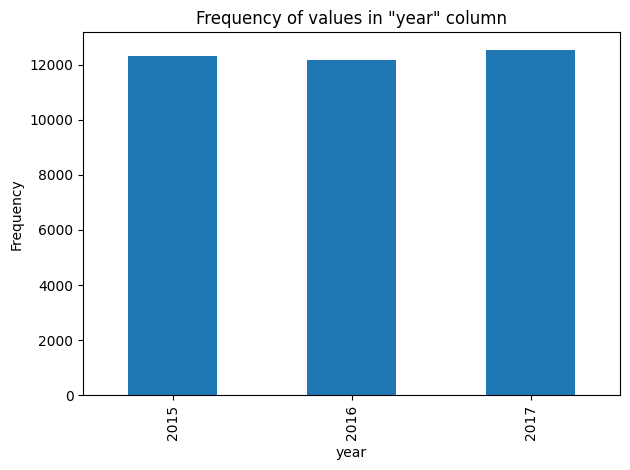

In [45]:
plot_frequency('year', df_new)

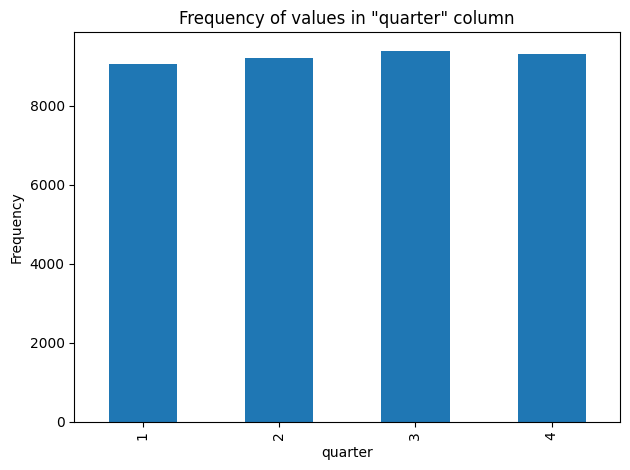

In [46]:
plot_frequency('quarter', df_new)

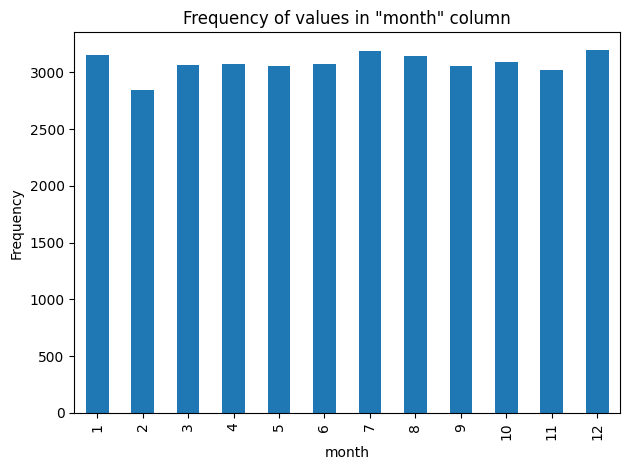

In [47]:
plot_frequency('month', df_new)

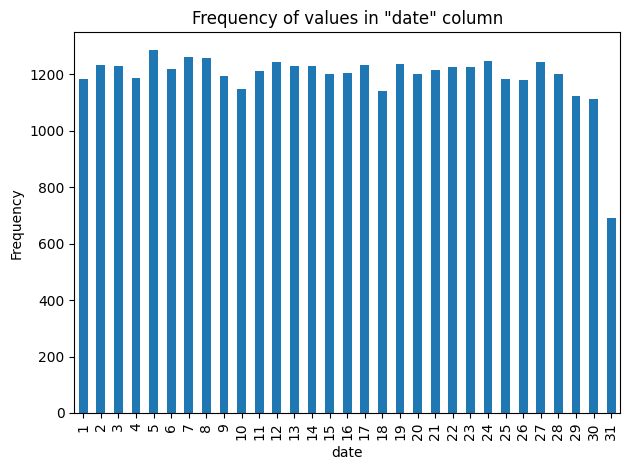

In [48]:
plot_frequency('date', df_new)

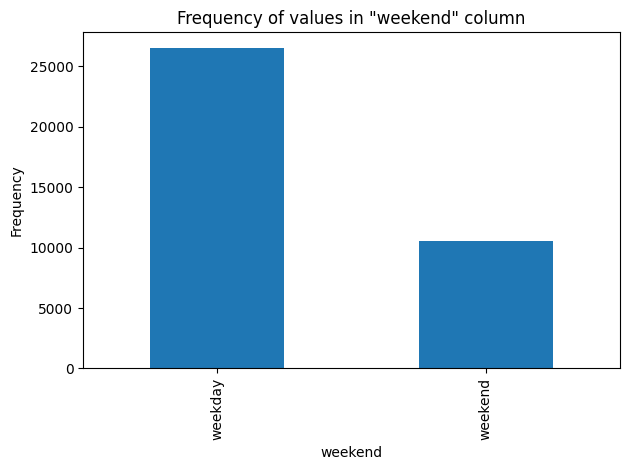

In [49]:
plot_frequency('weekend', df_new)

## Columns with mixed datatypes

In [64]:
mixed_numerical = ["avg_frequency_login_days"]
df[mixed_numerical].sample(10)

,avg_frequency_login_days
13315,14.0
14312,15.0
25404,17.0
19213,18.0
31374,29.0
23483,34.37113237434066
21234,12.0
10850,Error
16423,19.0
27445,25.0


In [74]:
import numpy as np
import re

In [78]:
float_pattern = r'^[-+]?\d*\.?\d+$'
bool(re.match(float_pattern, '17'))

True

In [79]:
df["avg_frequency_login_days"] = df["avg_frequency_login_days"].apply(lambda x : float(x) if bool(re.match(float_pattern, x)) else pd.NA)

In [ ]:
df["avg_frequency_login_days"].fillna()

0        17.0
1        10.0
2        22.0
3         6.0
4        16.0
         ... 
36987     6.0
36988    28.0
36989    <NA>
36990    20.0
36991    <NA>
Name: avg_frequency_login_days, Length: 36992, dtype: object

## Numerical Columns

Columns that have a numerical 

In [21]:
numerical_columns = ["days_since_last_login", "avg_time_spent", "avg_transaction_value", "points_in_wallet", "age", "churn_risk_score"]

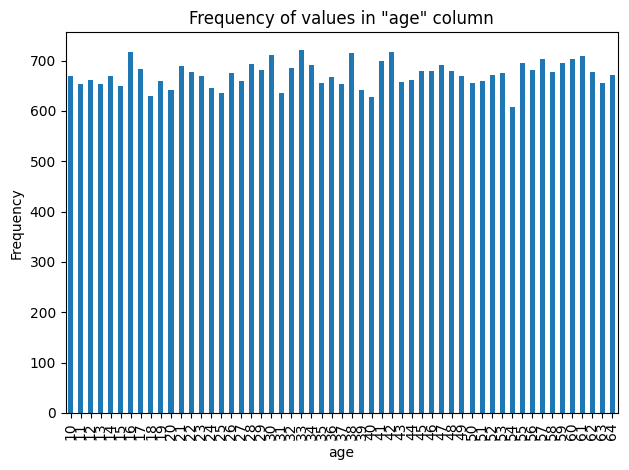

In [81]:
plot_frequency("age", df)

In [ ]:
plot_frequency("avg_time_spent", df)

In [22]:
df[numerical_columns].describe()

,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,age,churn_risk_score
count,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000,36992.000000
mean,-41.915576,243.472334,29271.194003,686.882199,37.118161,0.540982
std,228.819900,398.289149,19444.806226,194.063624,15.867412,0.498324
min,-999.000000,-2814.109110,800.460000,-760.661236,10.000000,0.000000
25%,8.000000,60.102500,14177.540000,616.150000,23.000000,0.000000
50%,12.000000,161.765000,27554.485000,697.620000,37.000000,1.000000
75%,16.000000,356.515000,40855.110000,763.950000,51.000000,1.000000
max,26.000000,3235.578521,99914.050000,2069.069761,64.000000,1.000000


## All other columns

In [51]:
other_columns = set(df.columns) - set(numerical_columns) - set(unclear_value_add_columns) - set(mixed_numerical)
other_columns

{'complaint_status',
 'feedback',
 'gender',
 'internet_option',
 'joined_through_referral',
 'joining_date',
 'last_visit_time',
 'medium_of_operation',
 'membership_category',
 'offer_application_preference',
 'past_complaint',
 'preferred_offer_types',
 'region_category',
 'used_special_discount'}

### Complaint Columns

In [ ]:
complaint_columns = ["complaint_status", "past_complaint"]

In [14]:
df.value_counts("feedback")

feedback
Poor Product Quality        6350
No reason specified         6290
Too many ads                6279
Poor Website                6271
Poor Customer Service       6252
Reasonable Price            1417
User Friendly Website       1391
Products always in Stock    1382
Quality Customer Care       1360
Name: count, dtype: int64